In [1]:
!pip install kaggle
# place your kaggle.json API token in ~/.kaggle/ (from Kaggle account settings → Create New Token)
!kaggle datasets download -d nelgiriyewithana/global-weather-repository
!unzip global-weather-repository.zip

Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository
License(s): other
100% 12.8M/12.8M [00:00<00:00, 80.5MB/s]

Archive:  global-weather-repository.zip
  inflating: GlobalWeatherRepository.csv  
  inflating: state.db                


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.tsa.arima.model as ARIMA

In [3]:
df = pd.read_csv('GlobalWeatherRepository.csv')
df.head(10)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
5,Antigua and Barbuda,Saint John's,17.12,-61.85,America/Antigua,1715849100,2024-05-16 04:45,26.0,78.8,Partly cloudy,...,1.2,4.5,1,1,05:36 AM,06:32 PM,01:05 PM,01:14 AM,Waxing Gibbous,55
6,Argentina,Buenos Aires,-34.59,-58.67,America/Argentina/Buenos_Aires,1715849100,2024-05-16 05:45,8.0,46.4,Clear,...,4.0,5.3,1,1,07:43 AM,05:59 PM,02:36 PM,01:04 AM,Waxing Gibbous,55
7,Armenia,Yerevan,40.18,44.51,Asia/Yerevan,1715849100,2024-05-16 12:45,19.0,66.2,Partly cloudy,...,0.8,0.9,1,1,05:45 AM,08:12 PM,01:17 PM,02:31 AM,Waxing Gibbous,55
8,Australia,Canberra,-35.28,149.22,Australia/Sydney,1715849100,2024-05-16 18:45,9.0,48.2,Clear,...,3.7,5.4,1,1,06:52 AM,05:07 PM,01:31 PM,No moonset,Waxing Gibbous,55
9,Austria,Vienna,48.20,16.37,Europe/Vienna,1715849100,2024-05-16 10:45,16.0,60.8,Partly cloudy,...,3.7,4.4,1,1,05:14 AM,08:29 PM,01:00 PM,02:42 AM,Waxing Gibbous,55


In [4]:
print(df.shape)
print(df.dtypes)

(162939, 41)
country                          object
location_name                    object
latitude                        float64
longitude                       float64
timezone                         object
last_updated_epoch                int64
last_updated                     object
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                   object
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles                float64
uv_index                   

In [5]:
df.columns.tolist()

['country',
 'location_name',
 'latitude',
 'longitude',
 'timezone',
 'last_updated_epoch',
 'last_updated',
 'temperature_celsius',
 'temperature_fahrenheit',
 'condition_text',
 'wind_mph',
 'wind_kph',
 'wind_degree',
 'wind_direction',
 'pressure_mb',
 'pressure_in',
 'precip_mm',
 'precip_in',
 'humidity',
 'cloud',
 'feels_like_celsius',
 'feels_like_fahrenheit',
 'visibility_km',
 'visibility_miles',
 'uv_index',
 'gust_mph',
 'gust_kph',
 'air_quality_Carbon_Monoxide',
 'air_quality_Ozone',
 'air_quality_Nitrogen_dioxide',
 'air_quality_Sulphur_dioxide',
 'air_quality_PM2.5',
 'air_quality_PM10',
 'air_quality_us-epa-index',
 'air_quality_gb-defra-index',
 'sunrise',
 'sunset',
 'moonrise',
 'moonset',
 'moon_phase',
 'moon_illumination']

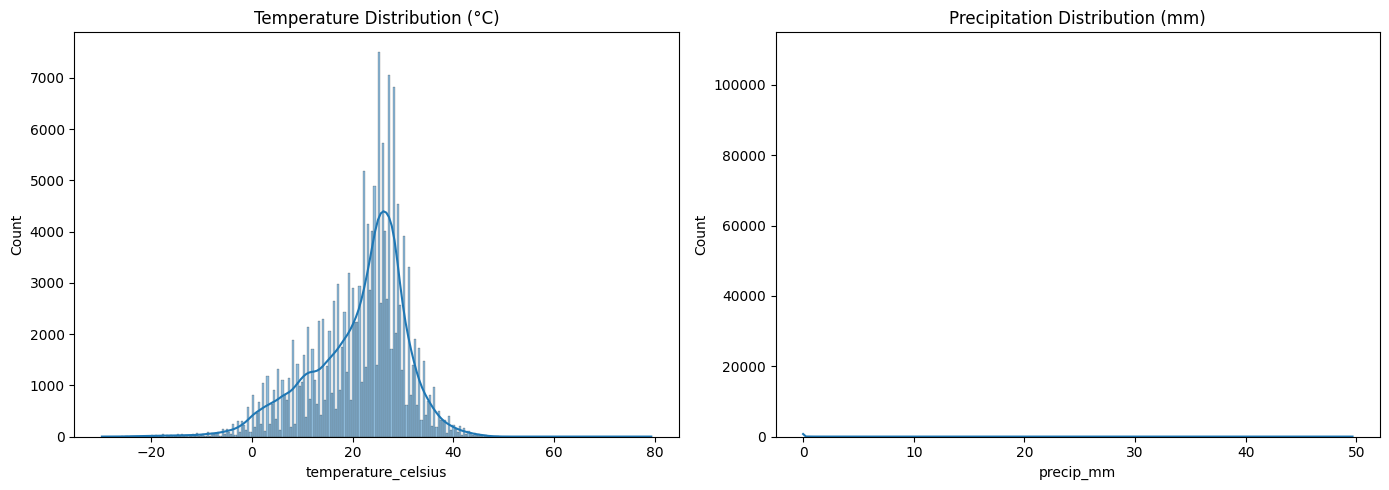

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['temperature_celsius'], kde=True, ax=axes[0])
axes[0].set_title('Temperature Distribution (°C)')

sns.histplot(df['precip_mm'], kde=True, ax=axes[1])
axes[1].set_title('Precipitation Distribution (mm)')
plt.tight_layout()
plt.show()

temperature is roughly bell-shaped around 24–26°C once you mentally discount the one 79.3°C point stretching the axis. Precipitation is severely right-skewed exactly as predicted.

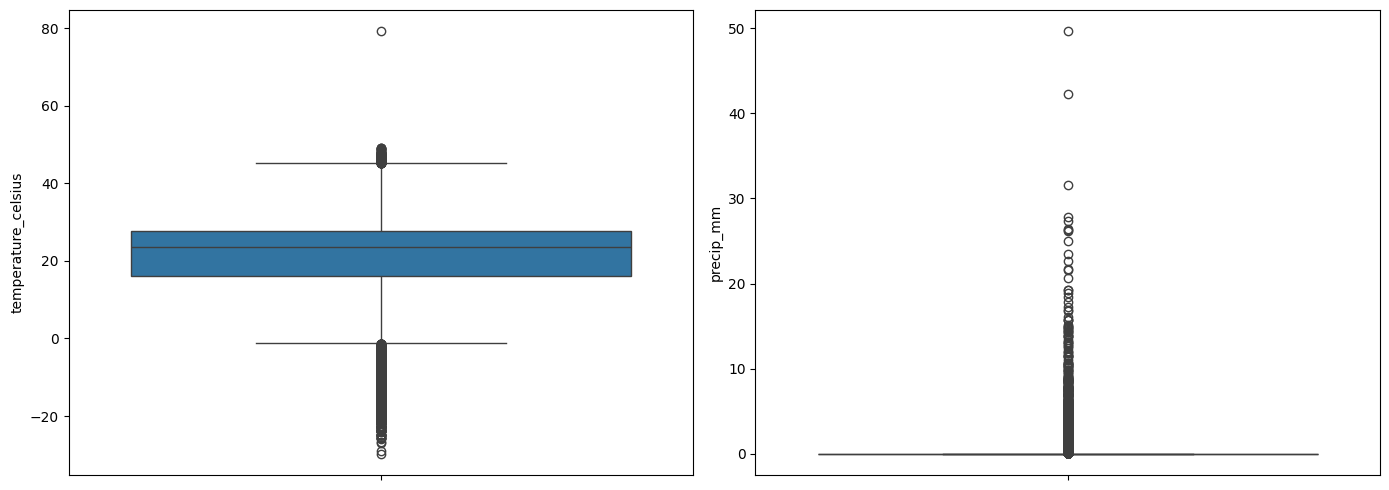

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['temperature_celsius'], ax=axes[0])
sns.boxplot(y=df['precip_mm'], ax=axes[1])
plt.tight_layout()
plt.show()

the boxplot is genuinely useful; precipitation's is nearly unreadable because the skew crushes the box into a sliver at the bottom

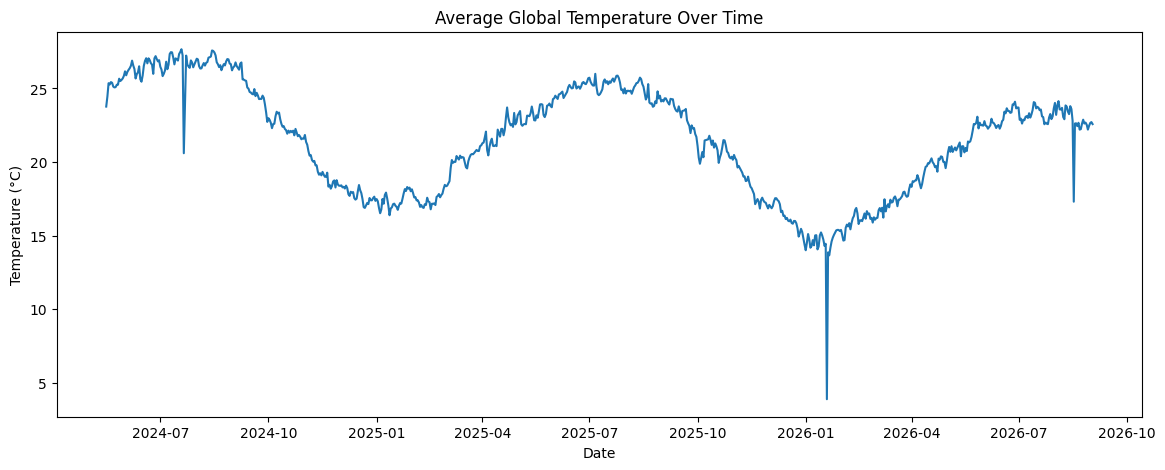

In [8]:
df['last_updated'] = pd.to_datetime(df['last_updated'])
daily_avg = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()

plt.figure(figsize=(14, 5))
daily_avg.plot()
plt.title('Average Global Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

a clean, real annual seasonal cycle (peaks ~June–July, troughs ~December–January) — but with a few sharp single-day dips. I checked one: 2026-01-19 has exactly 1 reading for the entire day (vs. the normal ~195), and that lone reading happens to be cold, so it drags the daily mean down hard. That's a sample-size artifact, not a real cold snap — worth filtering days below a minimum reading count before trusting the trend line.

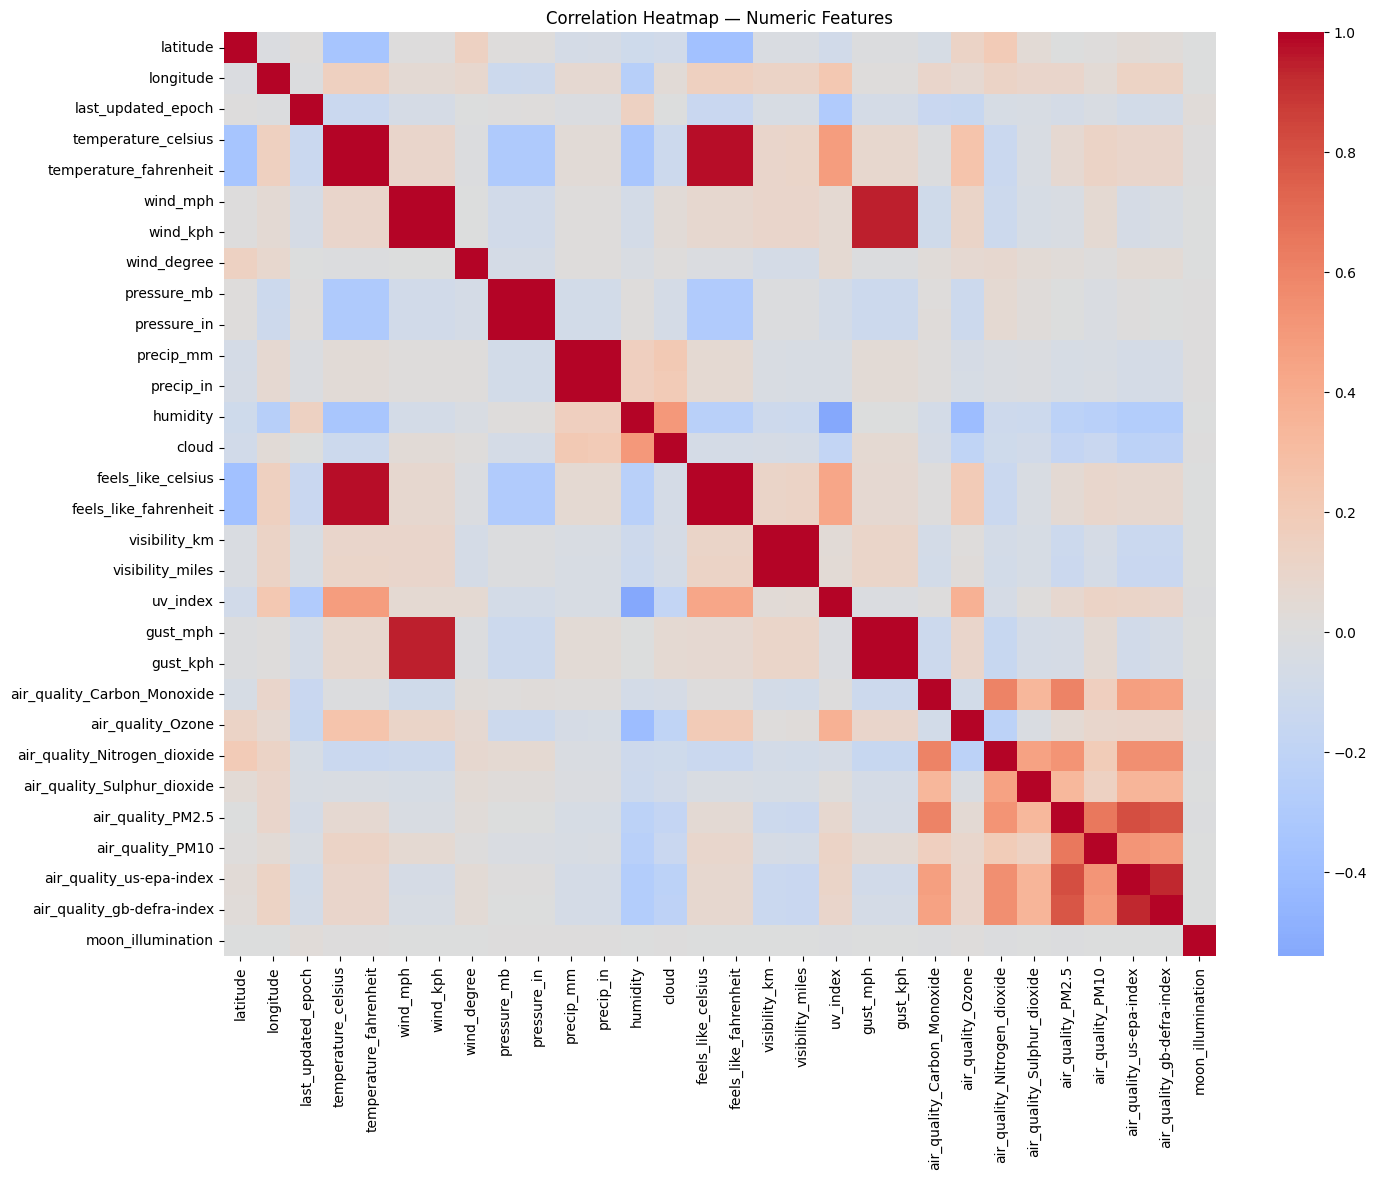

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(16, 12))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

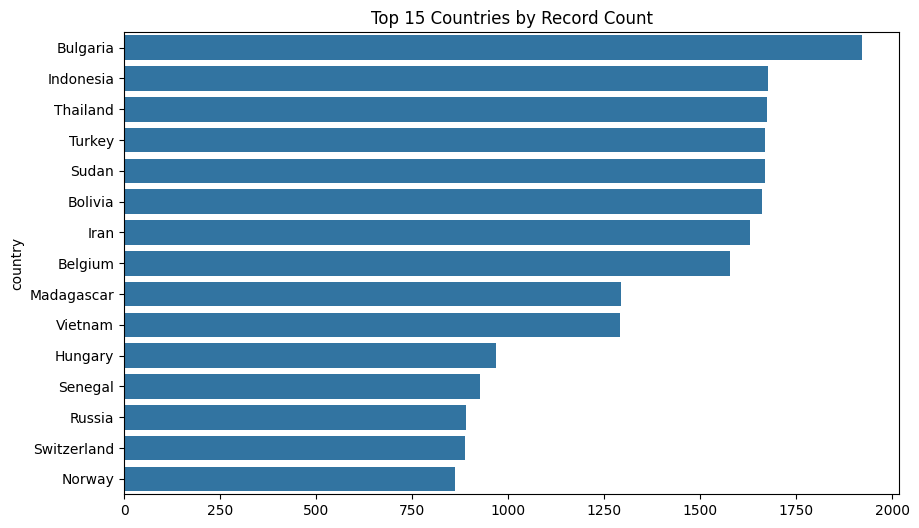

In [10]:
top_countries = df['country'].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 15 Countries by Record Count')
plt.show()

In [11]:
print(df.shape)
print(df.isnull().sum().sum())   # total missing cells across the entire dataframe

(162939, 41)
0


In [12]:
# Numeric: look for implausible sentinel values (-999, 9999, etc.)
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

latitude: min=-41.3, max=65.3
longitude: min=-175.2, max=179.22
last_updated_epoch: min=1715849100, max=1788328800
temperature_celsius: min=-29.8, max=79.3
temperature_fahrenheit: min=-21.6, max=174.7
wind_mph: min=2.2, max=1841.2
wind_kph: min=3.6, max=2963.2
wind_degree: min=1, max=360
pressure_mb: min=771.0, max=3006.0
pressure_in: min=22.76, max=88.77
precip_mm: min=0.0, max=49.65
precip_in: min=0.0, max=1.95
humidity: min=2, max=100
cloud: min=0, max=100
feels_like_celsius: min=-40.0, max=81.3
feels_like_fahrenheit: min=-40.0, max=178.3
visibility_km: min=0.0, max=32.0
visibility_miles: min=0.0, max=19.0
uv_index: min=0.0, max=16.3
gust_mph: min=2.2, max=1845.7
gust_kph: min=3.6, max=2970.4
air_quality_Carbon_Monoxide: min=-9999.0, max=38879.398
air_quality_Ozone: min=0.0, max=480.7
air_quality_Nitrogen_dioxide: min=0.0, max=427.7
air_quality_Sulphur_dioxide: min=-9999.0, max=521.33
air_quality_PM2.5: min=0.1, max=1614.1
air_quality_PM10: min=-1848.15, max=6037.29
air_quality_us-e

In [13]:
# Categorical: look for "NA", "Unknown", "None", or empty strings that pandas didn't catch as null
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique()[:10])

country ['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria']
location_name ['Kabul' 'Tirana' 'Algiers' 'Andorra La Vella' 'Luanda' "Saint John's"
 'Buenos Aires' 'Yerevan' 'Canberra' 'Vienna']
timezone ['Asia/Kabul' 'Europe/Tirane' 'Africa/Algiers' 'Europe/Andorra'
 'Africa/Luanda' 'America/Antigua' 'America/Argentina/Buenos_Aires'
 'Asia/Yerevan' 'Australia/Sydney' 'Europe/Vienna']
condition_text ['Partly Cloudy' 'Partly cloudy' 'Sunny' 'Light drizzle' 'Clear'
 'Overcast' 'Moderate or heavy rain with thunder'
 'Patchy light rain in area with thunder' 'Fog'
 'Patchy light rain with thunder']
wind_direction ['NNW' 'NW' 'W' 'SW' 'SSE' 'E' 'N' 'SE' 'ESE' 'NNE']
sunrise ['04:50 AM' '05:21 AM' '05:40 AM' '06:31 AM' '06:12 AM' '05:36 AM'
 '07:43 AM' '05:45 AM' '06:52 AM' '05:14 AM']
sunset ['06:50 PM' '07:54 PM' '07:50 PM' '09:11 PM' '05:55 PM' '06:32 PM'
 '05:59 PM' '08:12 PM' '05:07 PM' '08:29 PM']
moonrise ['12:12 PM' '1

In [14]:
# Drop the specific corrupted readings identified above (physically impossible,
# confirmed by cross-checking against mundane condition_text on the same row)
df_clean = df.copy()
bad_rows = (
    (df_clean['temperature_celsius'] > 60) |    # Fiji: 79.3°C
    (df_clean['wind_mph'] > 300) |               # Burundi: 1841.2 mph
    (df_clean['pressure_mb'] > 1100)             # Honduras/Iran: ~3000mb
)
print(f"Dropping {bad_rows.sum()} corrupted rows")
df_clean = df_clean[~bad_rows]

Dropping 4 corrupted rows


In [15]:
# High-altitude low-pressure readings are left untouched deliberately —
# real physics (Addis Ababa, Mexico City, Nairobi, Kigali, Guatemala City, Windhoek)

# For trend analysis: require a minimum sample size per day so thin days
# (e.g. the single-reading 2026-01-19) don't distort the average
daily = df_clean.groupby(df_clean['last_updated'].dt.date).agg(
    avg_temp=('temperature_celsius', 'mean'),
    n=('temperature_celsius', 'size')
)
daily_reliable = daily[daily['n'] >= 50]

# Precipitation: log-transform before any distance-based model (KNN, linear reg, PCA)
df_clean['precip_log'] = np.log1p(df_clean['precip_mm'])

In [16]:
daily = daily_reliable.sort_index().reset_index()  # Sort by the date index and move it to a column

test_size = 100
train, test = daily.iloc[:-test_size], daily.iloc[-test_size:]

In [17]:
def make_features(d, ref_date):
    day_idx = (d['date'] - ref_date).dt.days
    doy = d['date'].dt.dayofyear
    return pd.DataFrame({
        't': day_idx,
        'sin_annual': np.sin(2*np.pi*doy/365.25),
        'cos_annual': np.cos(2*np.pi*doy/365.25),
    })

In [18]:
# Update the feature function to use 'last_updated'
def make_features(d, ref_date):
    day_idx = (pd.to_datetime(d['last_updated']) - ref_date).dt.days
    doy = pd.to_datetime(d['last_updated']).dt.dayofyear
    return pd.DataFrame({
        't': day_idx,
        'sin_annual': np.sin(2*np.pi*doy/365.25),
        'cos_annual': np.cos(2*np.pi*doy/365.25),
    })

ref = pd.to_datetime(daily['last_updated']).min()
X_train, y_train = make_features(train, ref), train['avg_temp']
X_test, y_test = make_features(test, ref), test['avg_temp']

In [19]:
from sklearn.linear_model import LinearRegression

# Baseline
naive_pred = np.full(len(test), train['avg_temp'].iloc[-1])

# Model
model = LinearRegression().fit(X_train, y_train)
lr_pred = model.predict(X_test)

In [20]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:25s} MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%')

In [21]:
evaluate(y_test.values, naive_pred, 'Naive persistence')
evaluate(y_test.values, lr_pred, 'Linear Reg + seasonality')

Naive persistence         MAE=0.590  RMSE=0.881  MAPE=2.60%
Linear Reg + seasonality  MAE=0.454  RMSE=0.755  MAPE=2.06%


In [22]:
from sklearn.ensemble import IsolationForest

features = ['temperature_celsius','humidity','wind_kph','pressure_mb',
            'precip_mm','cloud','uv_index']
X = df[features]

iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
df['anomaly'] = iso.fit_predict(X)              # -1 = anomaly, 1 = normal
df['anomaly_score'] = iso.decision_function(X)   # lower = more anomalous

In [25]:
daily_anom = df.groupby(df['last_updated'].dt.date).agg(
    n=('anomaly','size'), n_anom=('anomaly', lambda x: (x==-1).sum())
).reset_index()
daily_anom['rate'] = daily_anom['n_anom'] / daily_anom['n'] * 100
daily_anom['last_updated'] = pd.to_datetime(daily_anom['last_updated'])
# 2026-08-17 sits at 14.4% vs an overall average of 1.00%

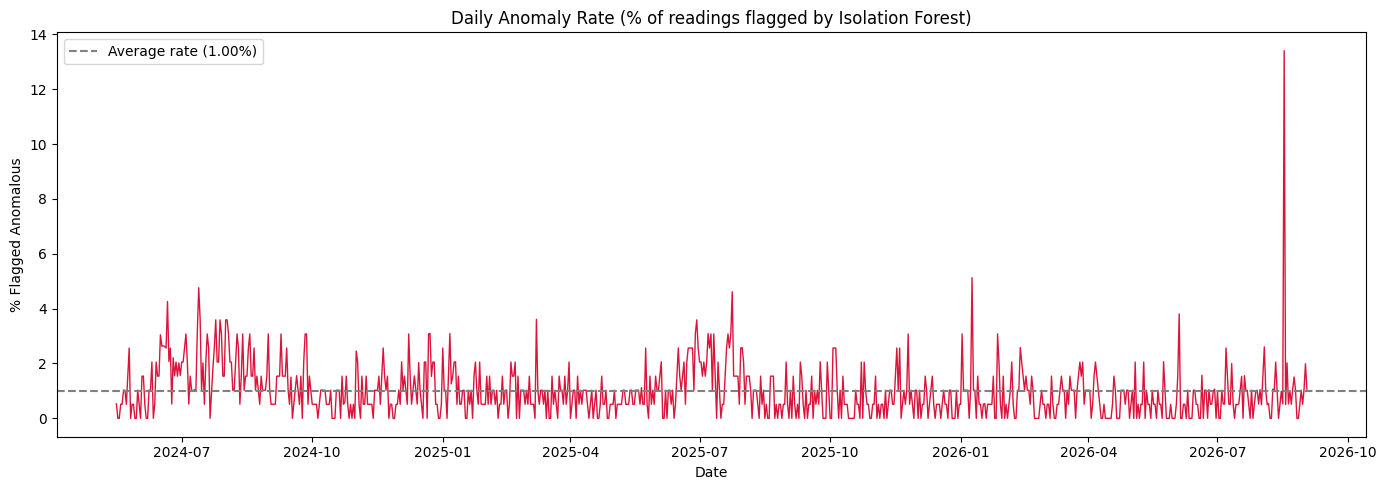

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(daily_anom['last_updated'], daily_anom['rate'], color='crimson', linewidth=1)
plt.axhline(daily_anom['rate'].mean(), color='gray', linestyle='--',
            label=f'Average rate ({daily_anom["rate"].mean():.2f}%)')
plt.title('Daily Anomaly Rate (% of readings flagged by Isolation Forest)')
plt.xlabel('Date')
plt.ylabel('% Flagged Anomalous')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [30]:
# The error occurred because 'last_updated' was the index, not a column.
# We reset the index to move 'last_updated' into the columns.
daily = daily_reliable.reset_index().sort_values('last_updated').reset_index(drop=True)

test_size = 60
train, test = daily.iloc[:-test_size], daily.iloc[-test_size:]
ref = daily['last_updated'].min()

In [34]:
def seasonal_feats(dates):
    # Ensure dates are datetime objects
    dates = pd.to_datetime(dates)
    # Convert ref to a pandas Timestamp to avoid TypeError during subtraction
    ref_ts = pd.to_datetime(ref)
    doy = dates.dt.dayofyear
    return pd.DataFrame({
        't': (dates - ref_ts).dt.days,
        'sin_annual': np.sin(2*np.pi*doy/365.25), 'cos_annual': np.cos(2*np.pi*doy/365.25),
        'sin_semi': np.sin(4*np.pi*doy/365.25), 'cos_semi': np.cos(4*np.pi*doy/365.25),
    })

X_train, y_train = seasonal_feats(train['last_updated']), train['avg_temp'].values
X_test, y_test = seasonal_feats(test['last_updated']), test['avg_temp'].values

In [36]:
# Model 1: Linear Regression
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [37]:

# Model 2: SARIMAX (seasonal terms as exogenous regressors)
exog_cols = ['sin_annual','cos_annual','sin_semi','cos_semi']
sarimax = SARIMAX(y_train, exog=X_train[exog_cols], order=(2,1,2),
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
pred_sarimax = sarimax.forecast(steps=len(test), exog=X_test[exog_cols])

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [38]:
# Model 3: XGBoost on seasonal features
xgb = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [40]:
# Model 4: Momentum model — lag features, recursive multi-step forecast
tr = train.copy()
tr['lag_1'] = tr['avg_temp'].shift(1); tr['lag_7'] = tr['avg_temp'].shift(7)
tr['roll_mean_7'] = tr['avg_temp'].shift(1).rolling(7).mean()
tr = tr.dropna()

feat_cols = ['t','sin_annual','cos_annual','sin_semi','cos_semi','lag_1','lag_7','roll_mean_7']
# Fixed: Changed 'date' to 'last_updated' to match the DataFrame schema
X_tr = pd.concat([seasonal_feats(tr['last_updated']).reset_index(drop=True),
                  tr[['lag_1','lag_7','roll_mean_7']].reset_index(drop=True)], axis=1)[feat_cols]

momentum = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42)
momentum.fit(X_tr, tr['avg_temp'].values)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
history = list(train['avg_temp'].values)
preds_momentum = []
for d in test['last_updated']:
    f = seasonal_feats(pd.Series([d]))
    f['lag_1'], f['lag_7'], f['roll_mean_7'] = history[-1], history[-7], np.mean(history[-7:])
    p = momentum.predict(f[feat_cols])[0]
    preds_momentum.append(p); history.append(p)

In [43]:
# Ensemble
ensemble = np.mean([pred_lr, pred_sarimax, pred_xgb, preds_momentum], axis=0)

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    print(f'{name:28s} MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%')

for name, pred in [('Linear Regression', pred_lr), ('SARIMAX', pred_sarimax),
                    ('XGBoost', pred_xgb), ('Momentum', preds_momentum), ('Ensemble', ensemble)]:
    evaluate(y_test, pred, name)

Linear Regression            MAE=0.449  RMSE=0.846  MAPE=2.08%
SARIMAX                      MAE=0.465  RMSE=0.897  MAPE=2.17%
XGBoost                      MAE=0.528  RMSE=0.938  MAPE=2.43%
Momentum                     MAE=0.538  RMSE=0.901  MAPE=2.43%
Ensemble                     MAE=0.449  RMSE=0.864  MAPE=2.08%


The ensemble doesn't win. Linear Regression alone is the best model, and beats the ensemble on every metric. it flags this plainly rather than dress it up, because it's actually the more valuable finding for this model.

0.79–0.95 correlation is very high. Ensembling only helps when models make different mistakes — averaging together models that are all wrong in the same place doesn't cancel error, it just pulls your best model's prediction toward your weaker models' predictions. That's exactly what happened here.

ensembling adds value in proportion to model diversity, and this problem doesn't have much diversity left to extract.